# FX Sentiment Analysis — Full Pipeline

**Project:** Multi-hop Reasoning for FX Headline Sentiment Classification  
**Model:** FLAN-T5-XXL (google/flan-t5-xxl)  
**Strategies evaluated:**
1. Single-prompt (zero-shot baseline)
2. Multi-hop chain-of-thought (4 hops, no context)
3. Hybrid RAG pipeline (direct vs. indirect routing + external context)

---
**How to run:** Execute cells top-to-bottom.  
All reusable components live in the `src/` package and can be imported independently.

## 0. Environment Setup

In [1]:
# Mount Google Drive (Colab only – comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Set working directory to project root (adjust path as needed)
%cd /content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/fx_sentiment

/content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/fx_sentiment


In [3]:
# Install dependencies
!pip install -q -U pip bitsandbytes
!pip install -q \
  transformers==4.38.2 \
  datasets==2.18.0 \
  accelerate==0.27.2 \
  sentencepiece \
  tqdm \
  scikit-learn \
  attrdict \
  seaborn \
  matplotlib

## 1. Load Model

In [4]:
from src.model_loader import load_model
import src.inference as inference

pipe = load_model()
inference.set_pipeline(pipe)  # share the pipeline with all strategy modules

# inspect GPU utilisation
!nvidia-smi

[model_loader] Loading tokenizer: google/flan-t5-xxl


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[model_loader] Loading model: google/flan-t5-xxl  (float16, device_map=auto)


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

[model_loader] Model ready.
Sat Feb 21 04:11:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             52W /  400W |   25538MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-------------------

## 2. Load Data

In [5]:
import pandas as pd
from src.config import (
    DEV_PATH, TEST_PATH,
    TEXT_COL, TICKER_COL, LABEL_COL, FINBERT_COL,
    IN_CONTEXT_COL, EX_CONTEXT_COLS,
)

df_dev  = pd.read_csv(DEV_PATH)
df_test = pd.read_csv(TEST_PATH)

# Use full dev set for evaluation (or sample for quick testing)
# sample_df = df_dev.sample(100, random_state=42).reset_index(drop=True)
sample_df = df_dev

print(f"Dev  : {len(df_dev):,} rows   |   Test : {len(df_test):,} rows")
df_dev.head(5)

Dev  : 1,829 rows   |   Test : 462 rows


,published_at,ticker,true_sentiment,title,author,url,source,text,finbert_sentiment,finbert_sent_score,external_context_1,external_context_2,external_context_3
0,2023-01-18 15:24:00,EURCHF,Negative,EURCHF Bias would be for stronger Franc but wa...,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-bias-wou...,FX Street,Economists at Credit Suisse are now neutral o...,Neutral,0.08,"Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B..."
1,2023-01-20 04:59:00,EURCHF,Negative,New lows for the EURUSD. EURCHF down as well a...,Greg Michalowski,https://www.forexlive.com/technical-analysis/n...,Forex Live,New low for the EURUSD as it remains the curre...,Negative,-0.93,European Stocks Climb Early in New Year: An ET...,Vanguard Real Estate ETF Experiences Big Outfl...,Vanguard Real Estate ETF Experiences Big Outfl...
2,2023-01-12 11:40:00,EURCHF,Neutral,Does a jump in EURCHF point to a break above 1...,FXStreet Insights Team,https://www.fxstreet.com/news/does-a-jump-in-e...,FX Street,EUR/CHF vaults parity for the first time since...,Neutral,0.37,"Down -29.05% in 4 Weeks, Here's Why You Should...",CEE MARKETS-FX drifts before U.S. inflation da...,Bear Market Watch: What Will Mean a Bull Marke...
3,2023-01-13 19:48:00,EURCHF,Neutral,USDCHF stalls its run higher at the 200 bar MA...,Greg Michalowski,https://www.forexlive.com/technical-analysis/u...,Forex Live,The USDCHF is sharply higher on the day helped...,Positive,0.77,CEE MARKETS-Forint climbs back near 5-month hi...,BBCA Breaks Above 200-Day Moving Average - Bul...,EWC Makes Bullish Cross Above Critical Moving ...
4,2023-01-12 07:47:00,EURCHF,Positive,Euro to benefit from the ECBs pronounced hawki...,FXStreet Insights Team,https://www.fxstreet.com/news/euro-to-benefit-...,FX Street,The Euro was able to appreciate particularly s...,Positive,0.85,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...,MOVES-Rothschild & Co appoint Horn as capital ...


## 3. Baseline 1: FinBERT Scores

=== FinBERT baseline — Dev ===

──────────────────────────────────────────────────
  FinBERT (Dev)
──────────────────────────────────────────────────
  Accuracy  : 0.5626
  Macro F1  : 0.5599

              precision    recall  f1-score   support

    Positive     0.5833    0.6176    0.6000       612
     Neutral     0.5361    0.4101    0.4648       651
    Negative     0.5622    0.6784    0.6149       566

    accuracy                         0.5626      1829
   macro avg     0.5606    0.5687    0.5599      1829
weighted avg     0.5600    0.5626    0.5565      1829



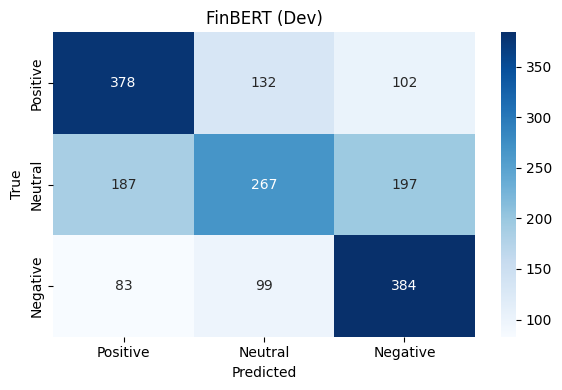


=== FinBERT baseline — Test ===

──────────────────────────────────────────────────
  FinBERT (Test)
──────────────────────────────────────────────────
  Accuracy  : 0.5584
  Macro F1  : 0.5554

              precision    recall  f1-score   support

    Positive     0.6174    0.5935    0.6053       155
     Neutral     0.5280    0.4024    0.4567       164
    Negative     0.5319    0.6993    0.6042       143

    accuracy                         0.5584       462
   macro avg     0.5591    0.5651    0.5554       462
weighted avg     0.5592    0.5584    0.5522       462



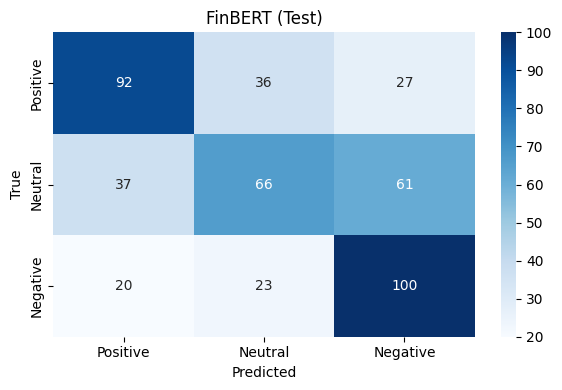

{'accuracy': 0.5584415584415584, 'macro_f1': 0.5554133899965943}

In [6]:
from src.evaluation import evaluate

print("=== FinBERT baseline — Dev ===")
evaluate(df_dev,  pred_col=FINBERT_COL, title="FinBERT (Dev)")

print("\n=== FinBERT baseline — Test ===")
evaluate(df_test, pred_col=FINBERT_COL, title="FinBERT (Test)")

## 4. Baseline 2: Single Prompt (Zero-shot)

One call per sample, no chain-of-thought.

Map:   0%|          | 0/1829 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(



──────────────────────────────────────────────────
  Single Prompt — Dev
──────────────────────────────────────────────────
  Accuracy  : 0.7190
  Macro F1  : 0.7123

              precision    recall  f1-score   support

    Positive     0.6109    0.9314    0.7379       612
     Neutral     0.8101    0.4455    0.5748       651
    Negative     0.8457    0.8039    0.8243       566

    accuracy                         0.7190      1829
   macro avg     0.7556    0.7269    0.7123      1829
weighted avg     0.7545    0.7190    0.7066      1829



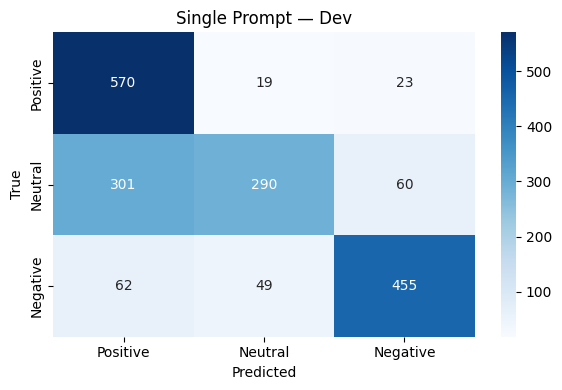

Map:   0%|          | 0/462 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(



──────────────────────────────────────────────────
  Single Prompt — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7078
  Macro F1  : 0.6948

              precision    recall  f1-score   support

    Positive     0.6198    0.9677    0.7557       155
     Neutral     0.7558    0.3963    0.5200       164
    Negative     0.8358    0.7832    0.8087       143

    accuracy                         0.7078       462
   macro avg     0.7372    0.7158    0.6948       462
weighted avg     0.7350    0.7078    0.6884       462



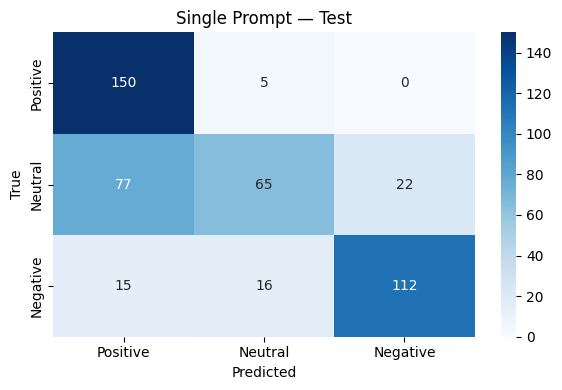

{'accuracy': 0.7077922077922078, 'macro_f1': 0.6947772554083423}

In [7]:
from tqdm import tqdm
from datasets import Dataset
from src.pipelines import single_prompt_pipeline
from src.config import RESULT_SINGLEPROMPT_DEV, RESULT_SINGLEPROMPT_TEST

def _run_single_prompt_batch(batch):
    from src.prompts import prompt_only
    prompts = [prompt_only(t, tk) for t, tk in zip(batch[TEXT_COL], batch[TICKER_COL])]
    outputs = pipe(prompts, max_new_tokens=5, truncation=True)
    batch["final_prediction"] = [o["generated_text"].strip() for o in outputs]
    return batch

# Dev
hf_dev = Dataset.from_pandas(sample_df)
hf_dev = hf_dev.map(_run_single_prompt_batch, batched=True, batch_size=8)
df_dev_sp = hf_dev.to_pandas()
df_dev_sp.to_csv(RESULT_SINGLEPROMPT_DEV, index=False)

evaluate(df_dev_sp, title="Single Prompt — Dev")

# Test
hf_test = Dataset.from_pandas(df_test)
hf_test = hf_test.map(_run_single_prompt_batch, batched=True, batch_size=8)
df_test_sp = hf_test.to_pandas()
df_test_sp.to_csv(RESULT_SINGLEPROMPT_TEST, index=False)

evaluate(df_test_sp, title="Single Prompt — Test")

## 5. Strategy 1: Multi-hop Chain-of-Thought

4 sequential hops per sample; no external context.

  0%|          | 0/1829 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 1829/1829 [20:02<00:00,  1.52it/s]



──────────────────────────────────────────────────
  Multi-hop — Dev
──────────────────────────────────────────────────
  Accuracy  : 0.7392
  Macro F1  : 0.7396

              precision    recall  f1-score   support

    Positive     0.6982    0.8807    0.7789       612
     Neutral     0.6828    0.6943    0.6885       651
    Negative     0.9139    0.6378    0.7513       566

    accuracy                         0.7392      1829
   macro avg     0.7650    0.7376    0.7396      1829
weighted avg     0.7595    0.7392    0.7382      1829



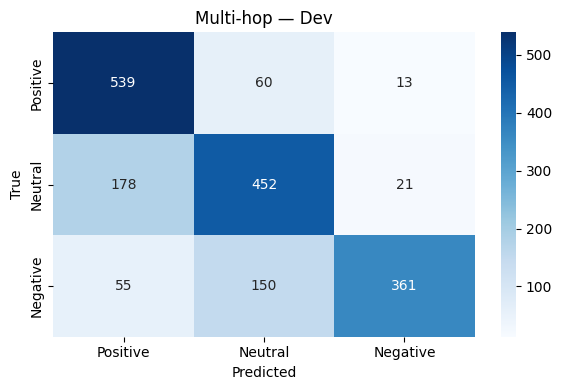

  0%|          | 0/462 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 462/462 [05:05<00:00,  1.51it/s]



──────────────────────────────────────────────────
  Multi-hop — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7641
  Macro F1  : 0.7616

              precision    recall  f1-score   support

    Positive     0.7487    0.9226    0.8266       155
     Neutral     0.7091    0.7134    0.7112       164
    Negative     0.8774    0.6503    0.7470       143

    accuracy                         0.7641       462
   macro avg     0.7784    0.7621    0.7616       462
weighted avg     0.7745    0.7641    0.7610       462



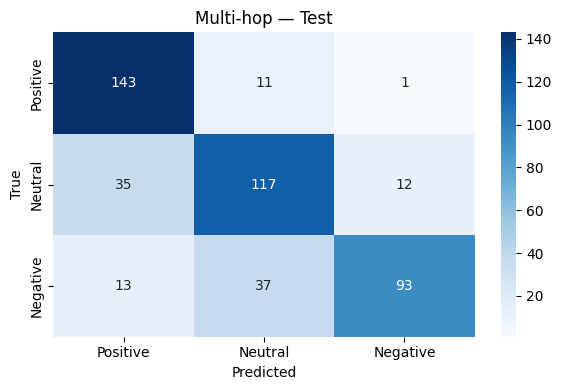

{'accuracy': 0.7640692640692641, 'macro_f1': 0.7616079159302848}

In [8]:
from src.pipelines import multihop_pipeline
from src.config import RESULT_MULTIHOP_DEV, RESULT_MULTIHOP_TEST

def _run_multihop(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        out = multihop_pipeline(row[TEXT_COL], row[TICKER_COL])
        records.append({
            "title": row[TEXT_COL],
            "ticker": row[TICKER_COL],
            "true_sentiment": row[LABEL_COL],
            "hop1_fx_insight": out["hop1"],
            "hop2_bc_sentiment": out["hop2_bc"],
            "hop3_qc_sentiment": out["hop3_qc"],
            "final_prediction": out["final"],
        })
    return pd.DataFrame(records)

# Dev
df_dev_mh = _run_multihop(sample_df)
df_dev_mh.to_csv(RESULT_MULTIHOP_DEV, index=False)
evaluate(df_dev_mh, title="Multi-hop — Dev")

# Test
df_test_mh = _run_multihop(df_test)
df_test_mh.to_csv(RESULT_MULTIHOP_TEST, index=False)
evaluate(df_test_mh, title="Multi-hop — Test")

## 6. Strategy 2: Hybrid Pipeline (no context)

Direct headlines → few-shot single step.  
Indirect headlines → 4-hop chain.

  0%|          | 0/1829 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 1829/1829 [07:50<00:00,  3.89it/s]



──────────────────────────────────────────────────
  Hybrid (no RAG) — Dev
──────────────────────────────────────────────────
  Accuracy  : 0.7600
  Macro F1  : 0.7612

              precision    recall  f1-score   support

    Positive     0.6818    0.9101    0.7796       612
     Neutral     0.7567    0.6498    0.6992       651
    Negative     0.9051    0.7244    0.8047       566

    accuracy                         0.7600      1829
   macro avg     0.7812    0.7614    0.7612      1829
weighted avg     0.7775    0.7600    0.7587      1829



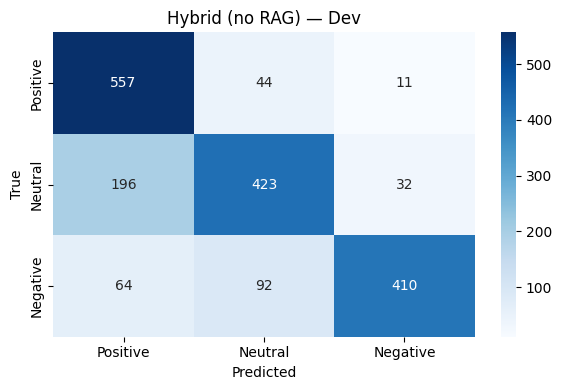

  0%|          | 0/462 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 462/462 [02:05<00:00,  3.69it/s]



──────────────────────────────────────────────────
  Hybrid (no RAG) — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7706
  Macro F1  : 0.7686

              precision    recall  f1-score   support

    Positive     0.7300    0.9419    0.8225       155
     Neutral     0.7483    0.6524    0.6971       164
    Negative     0.8655    0.7203    0.7863       143

    accuracy                         0.7706       462
   macro avg     0.7813    0.7716    0.7686       462
weighted avg     0.7784    0.7706    0.7668       462



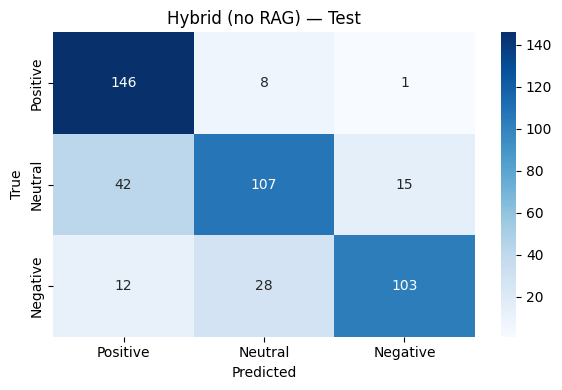

{'accuracy': 0.7705627705627706, 'macro_f1': 0.7686210523870445}

In [9]:
from src.pipelines import hybrid_rag_pipeline
from src.config import RESULT_HYBRID_DEV, RESULT_HYBRID_TEST

def _run_hybrid(df: pd.DataFrame, use_rag: bool = False) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        kwargs = dict(
            title=row[TEXT_COL],
            ticker=row[TICKER_COL],
        )
        if use_rag:
            kwargs.update(
                in_context=row.get(IN_CONTEXT_COL, ""),
                ex_context_1=row.get(EX_CONTEXT_COLS[0], ""),
                ex_context_2=row.get(EX_CONTEXT_COLS[1], ""),
                ex_context_3=row.get(EX_CONTEXT_COLS[2], ""),
            )
        out = hybrid_rag_pipeline(**kwargs)
        records.append({
            "mode": out["mode"],
            "title": row[TEXT_COL],
            "ticker": row[TICKER_COL],
            "true_sentiment": row[LABEL_COL],
            "hop1_fx_insight": out["hop1"],
            "hop2_bc_sentiment": out["hop2_bc"],
            "hop3_qc_sentiment": out["hop3_qc"],
            "final_prediction": out["final"],
        })
    return pd.DataFrame(records)

# Dev
df_dev_hy = _run_hybrid(sample_df, use_rag=False)
df_dev_hy.to_csv(RESULT_HYBRID_DEV, index=False)
evaluate(df_dev_hy, title="Hybrid (no RAG) — Dev")

# Test
df_test_hy = _run_hybrid(df_test, use_rag=False)
df_test_hy.to_csv(RESULT_HYBRID_TEST, index=False)
evaluate(df_test_hy, title="Hybrid (no RAG) — Test")

## 7. Strategy 3: Hybrid Pipeline (with context)

Same routing logic as Strategy 2, but indirect hops are augmented  
with in-domain (`text`) and external context columns.

  0%|          | 0/1829 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 1829/1829 [07:52<00:00,  3.87it/s]



──────────────────────────────────────────────────
  Hybrid RAG — Dev
──────────────────────────────────────────────────
  Accuracy  : 0.7611
  Macro F1  : 0.7622

              precision    recall  f1-score   support

    Positive     0.6860    0.9101    0.7823       612
     Neutral     0.7540    0.6544    0.7007       651
    Negative     0.9049    0.7226    0.8035       566

    accuracy                         0.7611      1829
   macro avg     0.7816    0.7624    0.7622      1829
weighted avg     0.7779    0.7611    0.7598      1829



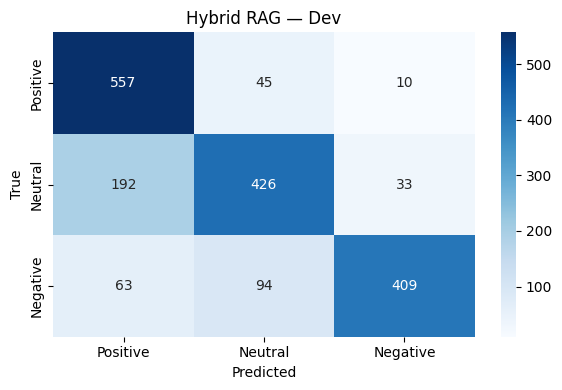

  0%|          | 0/462 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:410: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 462/462 [02:07<00:00,  3.62it/s]



──────────────────────────────────────────────────
  Hybrid RAG — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7684
  Macro F1  : 0.7669

              precision    recall  f1-score   support

    Positive     0.7286    0.9355    0.8192       155
     Neutral     0.7397    0.6585    0.6968       164
    Negative     0.8718    0.7133    0.7846       143

    accuracy                         0.7684       462
   macro avg     0.7801    0.7691    0.7669       462
weighted avg     0.7769    0.7684    0.7650       462



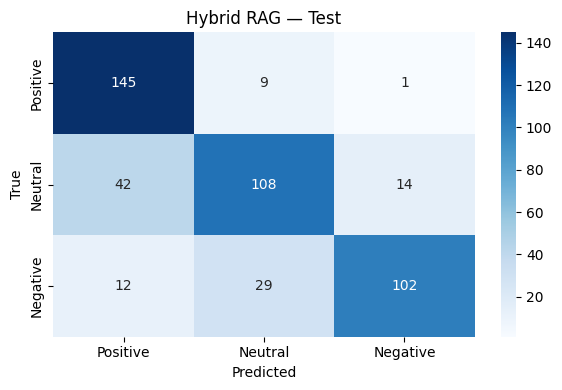

{'accuracy': 0.7683982683982684, 'macro_f1': 0.7668662059039314}

In [10]:
from src.config import RESULT_HYBRID_RAG_DEV, RESULT_HYBRID_RAG_TEST
from src.pipelines import hybrid_rag_pipeline

# Dev
df_dev_rag = _run_hybrid(sample_df, use_rag=True)
df_dev_rag.to_csv(RESULT_HYBRID_RAG_DEV, index=False)
evaluate(df_dev_rag, title="Hybrid RAG — Dev")

# Test
df_test_rag = _run_hybrid(df_test, use_rag=True)
df_test_rag.to_csv(RESULT_HYBRID_RAG_TEST, index=False)
evaluate(df_test_rag, title="Hybrid RAG — Test")

## 8. Summary Comparison

                Strategy  Dev Accuracy  Dev Macro F1  Test Accuracy  Test Macro F1
      FinBERT (baseline)        0.5626        0.5599         0.5584         0.5554
Single Prompt (baseline)        0.7190        0.7123         0.7078         0.6948
               Multi-hop        0.7392        0.7396         0.7641         0.7616
         Hybrid (no RAG)        0.7600        0.7612         0.7706         0.7686
       Hybrid (with RAG)        0.7611        0.7622         0.7684         0.7669


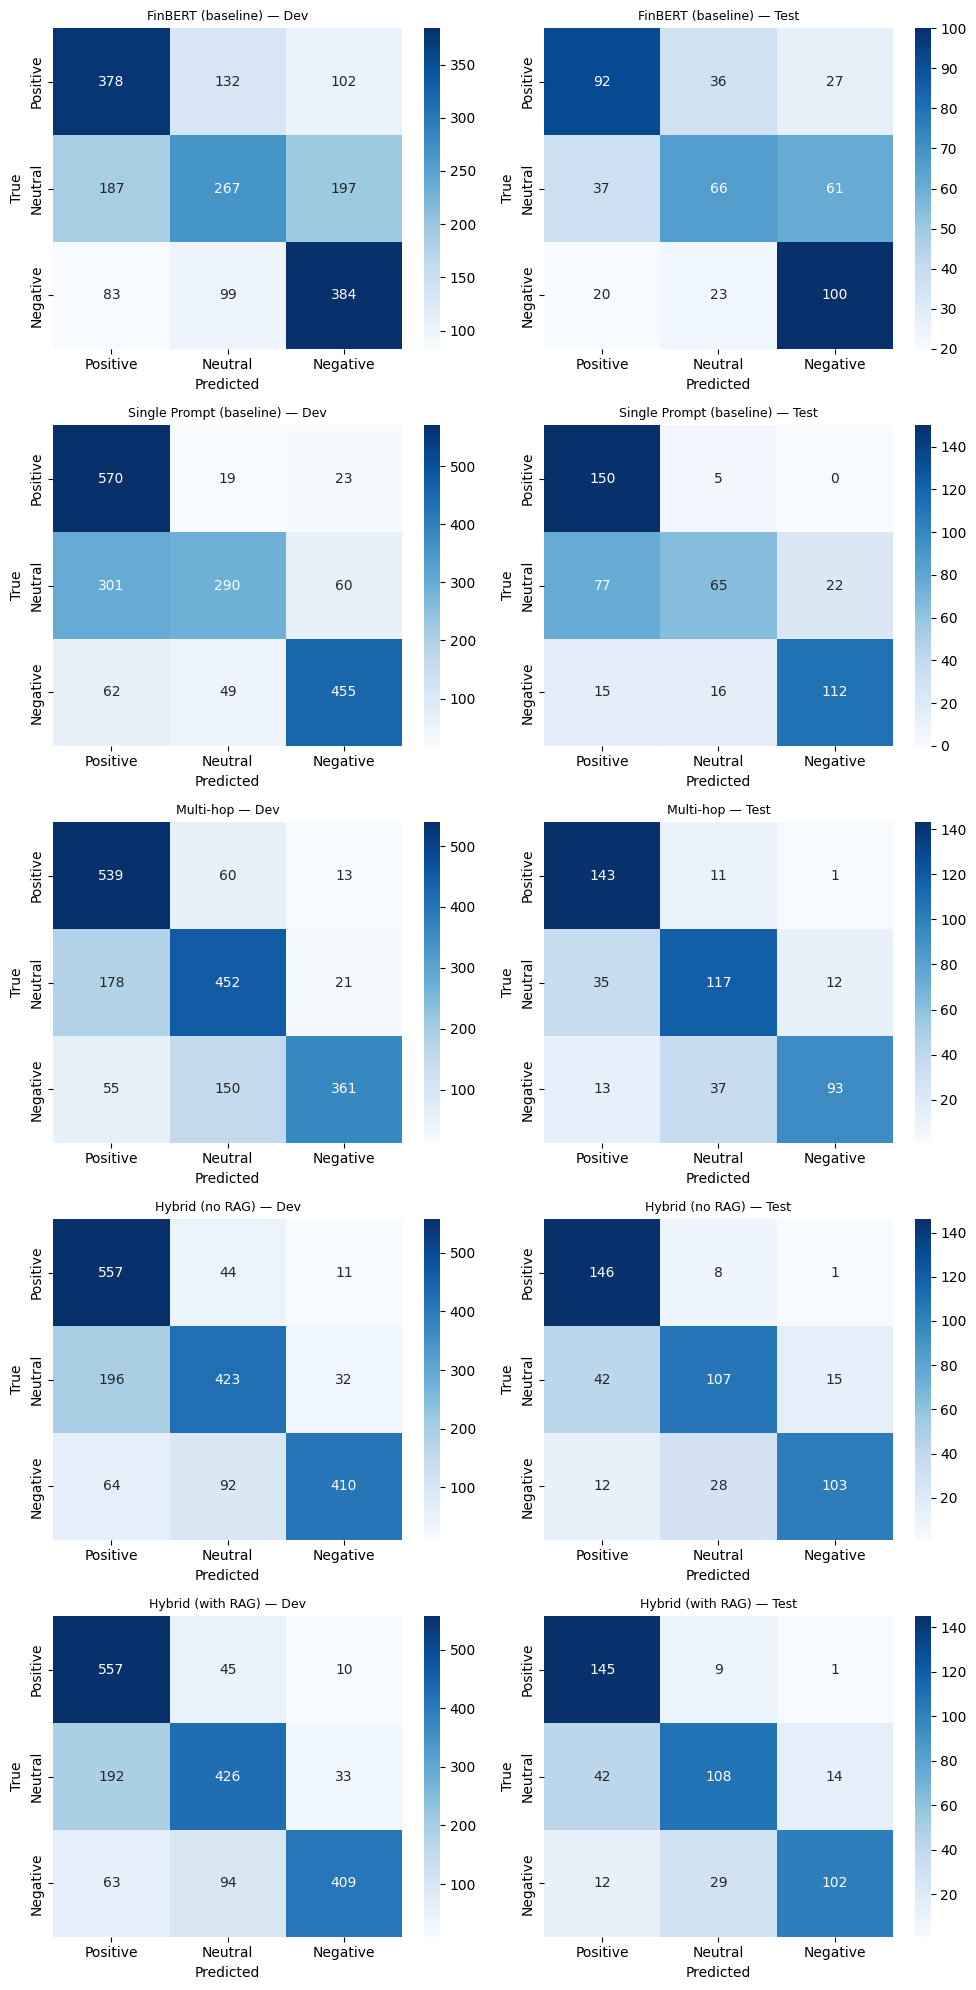

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from src.config import LABEL_COL, FINBERT_COL, LABELS

def compute_metrics(df, pred_col):
    acc = accuracy_score(df[LABEL_COL], df[pred_col])
    f1  = f1_score(df[LABEL_COL], df[pred_col], average="macro", zero_division=0)
    return round(acc, 4), round(f1, 4)

def plot_confusion_matrix(ax, df, pred_col, title):
    cm = confusion_matrix(df[LABEL_COL], df[pred_col], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

strategies = [
    ("FinBERT (baseline)", df_dev,     df_test,     FINBERT_COL),
    ("Single Prompt (baseline)",      df_dev_sp,  df_test_sp,  "final_prediction"),
    ("Multi-hop",          df_dev_mh,  df_test_mh,  "final_prediction"),
    ("Hybrid (no RAG)",    df_dev_hy,  df_test_hy,  "final_prediction"),
    ("Hybrid (with RAG)",         df_dev_rag, df_test_rag, "final_prediction"),
]

# Summary table
results = []
for name, dev_df, test_df, pred_col in strategies:
    dev_acc,  dev_f1  = compute_metrics(dev_df,  pred_col)
    test_acc, test_f1 = compute_metrics(test_df, pred_col)
    results.append({
        "Strategy":      name,
        "Dev Accuracy":  dev_acc,
        "Dev Macro F1":  dev_f1,
        "Test Accuracy": test_acc,
        "Test Macro F1": test_f1,
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
summary.to_csv("data/finance/comparison_all_models.csv", index=False)

# ── Confusion matrices (Dev | Test per strategy)
fig, axes = plt.subplots(
    nrows=len(strategies), ncols=2,
    figsize=(10, 4 * len(strategies))
)

for row, (name, dev_df, test_df, pred_col) in enumerate(strategies):
    plot_confusion_matrix(axes[row, 0], dev_df,  pred_col, f"{name} — Dev")
    plot_confusion_matrix(axes[row, 1], test_df, pred_col, f"{name} — Test")

plt.tight_layout()
plt.show()

In [12]:
merged = df_dev[[TEXT_COL, TICKER_COL, LABEL_COL, IN_CONTEXT_COL, *EX_CONTEXT_COLS]].copy()

# FinBERT
merged["pred_finbert"] = df_dev[FINBERT_COL].values

# Single Prompt
merged["pred_singleprompt"] = df_dev_sp["final_prediction"].values

# Multi-hop
merged["pred_multihop"]            = df_dev_mh["final_prediction"].values
merged["multihop_hop1_fx_insight"] = df_dev_mh["hop1_fx_insight"].values
merged["multihop_hop2_bc"]         = df_dev_mh["hop2_bc_sentiment"].values
merged["multihop_hop3_qc"]         = df_dev_mh["hop3_qc_sentiment"].values

# Hybrid (no RAG)
merged["pred_hybrid"]        = df_dev_hy["final_prediction"].values
merged["hybrid_mode"]        = df_dev_hy["mode"].values
merged["hybrid_hop1_fx_insight"] = df_dev_hy["hop1_fx_insight"].values
merged["hybrid_hop2_bc"]     = df_dev_hy["hop2_bc_sentiment"].values
merged["hybrid_hop3_qc"]     = df_dev_hy["hop3_qc_sentiment"].values

# Hybrid RAG
merged["pred_hybrid_rag"]        = df_dev_rag["final_prediction"].values
merged["hybrid_rag_mode"]        = df_dev_rag["mode"].values
merged["hybrid_rag_hop1_fx_insight"] = df_dev_rag["hop1_fx_insight"].values
merged["hybrid_rag_hop2_bc"]     = df_dev_rag["hop2_bc_sentiment"].values
merged["hybrid_rag_hop3_qc"]     = df_dev_rag["hop3_qc_sentiment"].values

merged.to_csv("data/finance/all_predictions.csv", index=False)
print("Saved → data/finance/all_predictions.csv")
merged.head()

Saved → data/finance/all_predictions.csv


,title,ticker,true_sentiment,text,external_context_1,external_context_2,external_context_3,pred_finbert,pred_singleprompt,pred_multihop,...,pred_hybrid,hybrid_mode,hybrid_hop1_fx_insight,hybrid_hop2_bc,hybrid_hop3_qc,pred_hybrid_rag,hybrid_rag_mode,hybrid_rag_hop1_fx_insight,hybrid_rag_hop2_bc,hybrid_rag_hop3_qc
0,EURCHF Bias would be for stronger Franc but wa...,EURCHF,Negative,Economists at Credit Suisse are now neutral o...,"Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B...","Financial Sector Update for 01/18/2023: PNC, B...",Neutral,Neutral,Neutral,...,Neutral,direct,None,None,None,Neutral,direct,None,None,None
1,New lows for the EURUSD. EURCHF down as well a...,EURCHF,Negative,New low for the EURUSD as it remains the curre...,European Stocks Climb Early in New Year: An ET...,Vanguard Real Estate ETF Experiences Big Outfl...,Vanguard Real Estate ETF Experiences Big Outfl...,Negative,Negative,Negative,...,Negative,direct,None,None,None,Negative,direct,None,None,None
2,Does a jump in EURCHF point to a break above 1...,EURCHF,Neutral,EUR/CHF vaults parity for the first time since...,"Down -29.05% in 4 Weeks, Here's Why You Should...",CEE MARKETS-FX drifts before U.S. inflation da...,Bear Market Watch: What Will Mean a Bull Marke...,Neutral,Positive,Positive,...,Positive,direct,None,None,None,Positive,direct,None,None,None
3,USDCHF stalls its run higher at the 200 bar MA...,EURCHF,Neutral,The USDCHF is sharply higher on the day helped...,CEE MARKETS-Forint climbs back near 5-month hi...,BBCA Breaks Above 200-Day Moving Average - Bul...,EWC Makes Bullish Cross Above Critical Moving ...,Positive,Neutral,Neutral,...,Neutral,indirect,No clear pressure,Neutral,Neutral,Neutral,indirect,No clear pressure,Neutral,Neutral
4,Euro to benefit from the ECBs pronounced hawki...,EURCHF,Positive,The Euro was able to appreciate particularly s...,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...,MOVES-Rothschild & Co appoint Horn as capital ...,Positive,Positive,Positive,...,Positive,indirect,Upward pressure,Positive,Neutral,Positive,indirect,Upward pressure,Positive,Neutral
